In [30]:
import numpy as np

from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras import layers

import tensorflow as tf
import matplotlib.pyplot as plt
import math

In [18]:
def load_emnist_raw(filepath, offset, shape=None):
    with open(filepath, 'rb') as f:
        data = np.frombuffer(f.read(), dtype=np.uint8, offset=offset)
    if shape:
        return data.reshape(-1, *shape)
    return data

In [19]:
x_train = load_emnist_raw('.zips/byclass-train-images.gz', offset=16, shape=(28,28))
y_train = load_emnist_raw('.zips/byclass-train-labels.gz', offset=8)
x_train = np.transpose(x_train, (0, 2, 1))

x_test = load_emnist_raw('.zips/byclass-test-images.gz', offset=16, shape=(28,28))
y_test = load_emnist_raw('.zips/byclass-test-labels.gz', offset=8)
x_test = np.transpose(x_test, (0, 2, 1))

In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

epochs = 15
num_classes = 62
batch_size = 128
buffer_size = 10000
steps_per_epoch = int(np.ceil(x_train.shape[0] / float(batch_size)))

model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])


# x_train = x_train.reshape(-1, 28, 28, 1)
# x_test = x_test.reshape(-1, 28, 28, 1)
# model = tf.keras.models.Sequential([
#     tf.keras.layers.Input((28, 28)),
#     tf.keras.layers.Reshape((28, 28, 1)), # Нужен для сверток
#     tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
#     tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
#     tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
#     tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
#     tf.keras.layers.Flatten(),
#     tf.keras.layers.Dense(256, activation='relu'),
#     tf.keras.layers.Dropout(0.3),
#     tf.keras.layers.Dense(num_classes, activation='softmax')
# ])

model.compile (
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
    )

model.fit(x_train, y_train, epochs = epochs, batch_size = batch_size, steps_per_epoch = steps_per_epoch)
loss, acc = model.evaluate(x_test, y_test, num_classes, verbose=2)
print('\nTest accuracy: {0}'.format(acc))


Epoch 1/15
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.7764 - loss: 0.7258
Epoch 2/15
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.8279 - loss: 0.5148
Epoch 3/15
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.8377 - loss: 0.4757
Epoch 4/15
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.8430 - loss: 0.4553
Epoch 5/15
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.8466 - loss: 0.4412
Epoch 6/15
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.8491 - loss: 0.4298
Epoch 7/15
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.8518 - loss: 0.4210
Epoch 8/15
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.8530 - loss: 0.4133
Epoch 9/15
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.8543 - loss: 0.4078
Epoch 10/15
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.8560 - loss: 0.4034
Epoch 11/15
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.8573 - loss: 0.3979
Epoch 12/15
5453/54

909/909 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


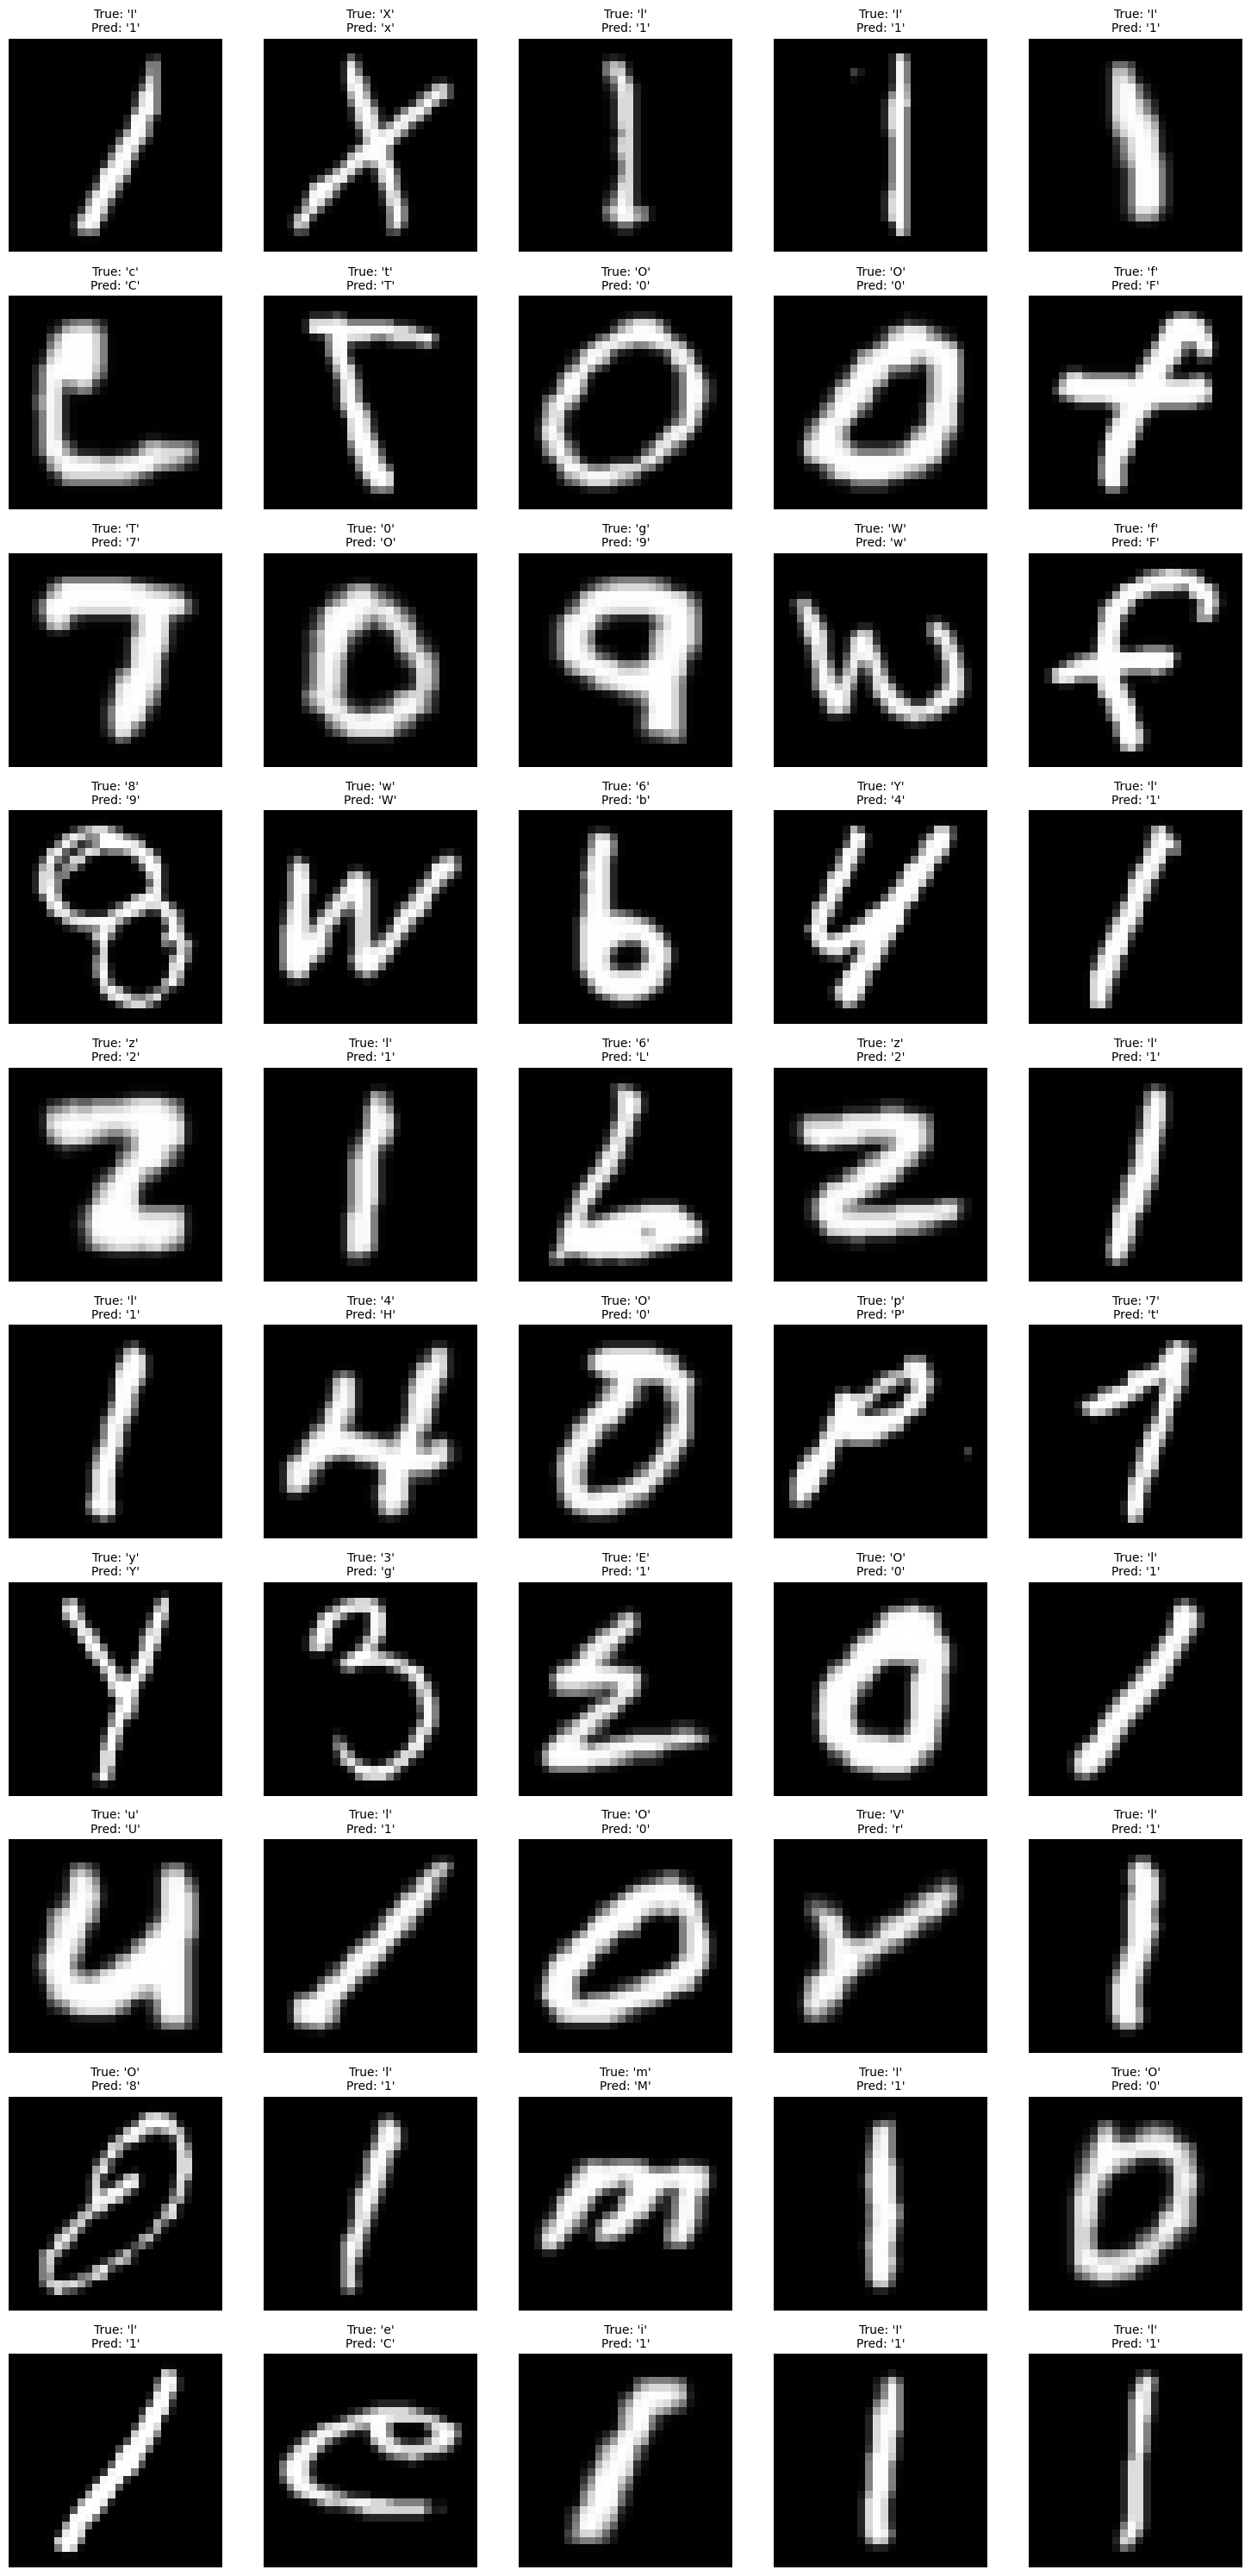

In [32]:
emnist_labels = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"

predictions = model.predict(x_test, batch_size=batch_size)
predicted_labels = np.argmax(predictions, axis=1)

errors = np.where(predicted_labels != y_test)[0]

def show_errors(images, true_labels, pred_labels, error_indices, n=50):
    # Автоматически считаем количество строк, исходя из 5 столбцов
    cols = 5
    rows = math.ceil(n / cols) 
    
    plt.figure(figsize=(15, rows * 3)) # Высота окна подстроится под кол-во строк
    
    for i in range(min(n, len(error_indices))):
        idx = error_indices[i]
        true_char = emnist_labels[true_labels[idx]]
        pred_char = emnist_labels[pred_labels[idx]]
        
        # Теперь subplot динамически использует rows и cols
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[idx], cmap='gray')
        
        plt.title(f"True: '{true_char}'\nPred: '{pred_char}'", fontsize=10)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

show_errors(x_test, y_test, predicted_labels, errors)

In [33]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((28, 28)),
    tf.keras.layers.Reshape((28, 28, 1)), # Нужен для сверток
    tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])


model.compile (
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
    )

model.fit(x_train, y_train, epochs = epochs, batch_size = batch_size, steps_per_epoch = steps_per_epoch)
loss, acc = model.evaluate(x_test, y_test, num_classes, verbose=2)
print('\nTest accuracy: {0}'.format(acc))


Epoch 1/15
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 45s 8ms/step - accuracy: 0.8138 - loss: 0.5626
Epoch 2/15
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 44s 8ms/step - accuracy: 0.8505 - loss: 0.4177
Epoch 3/15
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 44s 8ms/step - accuracy: 0.8582 - loss: 0.3898
Epoch 4/15
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 44s 8ms/step - accuracy: 0.8627 - loss: 0.3732
Epoch 5/15
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 44s 8ms/step - accuracy: 0.8660 - loss: 0.3610
Epoch 6/15
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 45s 8ms/step - accuracy: 0.8689 - loss: 0.3520
Epoch 7/15
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 45s 8ms/step - accuracy: 0.8704 - loss: 0.3444
Epoch 8/15
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 46s 8ms/step - accuracy: 0.8723 - loss: 0.3375
Epoch 9/15
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 45s 8ms/step - accuracy: 0.8738 - loss: 0.3306
Epoch 10/15
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 46s 8ms/step - accuracy: 0.8756 - loss: 0.3262
Epoch 11/15
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 45s 8ms/step - accuracy: 0.8771 - loss: 0.3212
Epoch 12/15
5453/54

909/909 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


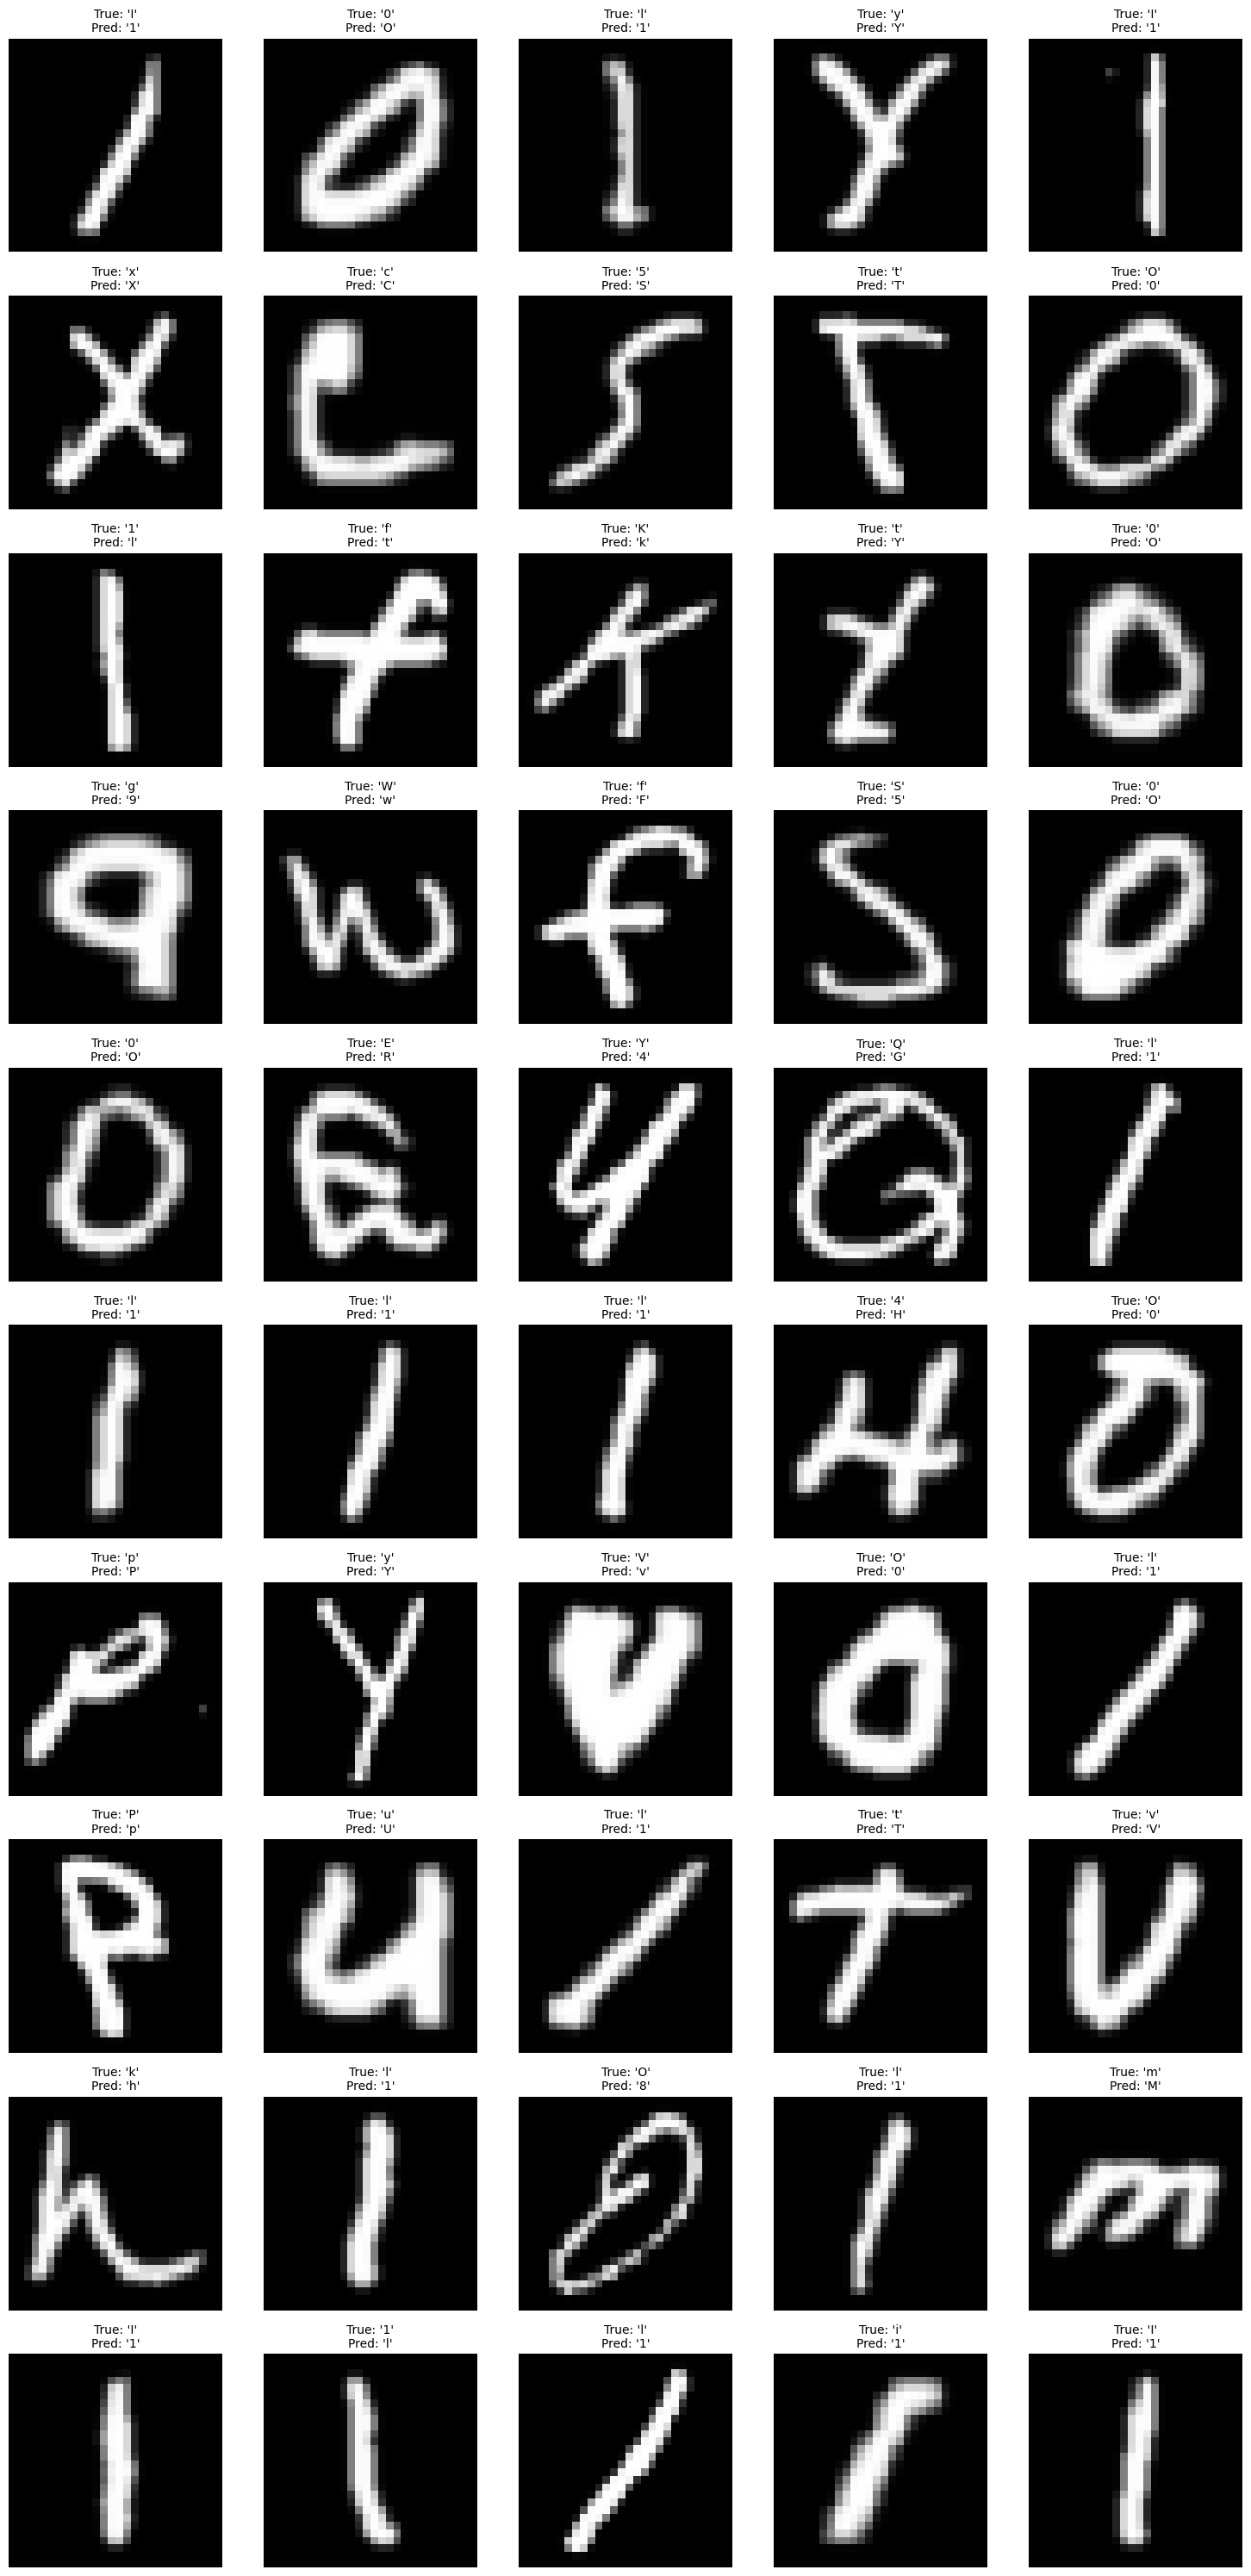

In [ ]:
predictions = model.predict(x_test, batch_size=batch_size)
predicted_labels = np.argmax(predictions, axis=1)

errors = np.where(predicted_labels != y_test)[0]

show_errors(x_test, y_test, predicted_labels, errors)